# Known-Pose Reconstruction

This notebook follows the same high-level structure as `reconstruction.ipynb`, but it builds the COLMAP map with camera poses from `metadata/poses.json`. Images are still used for feature extraction, matching, and 3D point triangulation; only camera pose estimation is replaced by known ground-truth poses.

The image selection is camera-agnostic: choose `source_images_dir` and `image_glob`, and the notebook matches selected image basenames to `poses.json`.

## 1. Configuration

In [1]:
from pathlib import Path
from datetime import datetime
import json
import shutil

import numpy as np

from hloc import extract_features, match_features, pairs_from_retrieval, triangulation

from reconstruct_known_pose import write_known_pose_text_model, alignment_report
from simulation_pose_utils import image_basename, load_pose_records, print_dataset_report, validate_camera_dataset

# Source dataset with metadata/poses.json, metadata/poses_detailed.json, and intrinsics.
source_dataset = Path('../datasets/sim_images_19_may')

# Mapping/train images. This can be front, back, or any camera subset as long as basenames exist in poses.json.
source_images_dir = source_dataset / 'images'
image_glob = '*.png'

# Optional metadata filter. Use None to infer from selected image basenames.
# Example: camera_names = ['front'] or ['back']
camera_names = None

# Output bundle for this known-pose reconstruction.
portable_root = Path('../outputs/sim-19-may-bundle')
portable_images_dir = portable_root / 'images'
sparse_input_dir = portable_root / 'sparse_input'
sfm_dir = portable_root / 'sfm'
portable_sparse_dir = portable_root / 'sparse'
reset_bundle = True

# HLoc/COLMAP artifact paths.
sfm_pairs = portable_root / 'pairs-sfm.txt'
features = portable_root / 'features.h5'
global_features = portable_root / 'global-feats-netvlad.h5'
matches = portable_root / 'matches.h5'
portable_database = sfm_dir / 'database.db'
portable_metadata = portable_root / 'metadata.json'

# Feature/retrieval/matcher configurations.
feature_conf = extract_features.confs['superpoint_max']
retrieval_conf = extract_features.confs['netvlad']
matcher_conf = match_features.confs['superpoint+lightglue']
num_matched = 20

if reset_bundle and portable_root.exists():
    shutil.rmtree(portable_root)

portable_root.mkdir(parents=True, exist_ok=True)
portable_images_dir.mkdir(parents=True, exist_ok=True)
sparse_input_dir.mkdir(parents=True, exist_ok=True)
sfm_dir.mkdir(parents=True, exist_ok=True)
portable_sparse_dir.mkdir(parents=True, exist_ok=True)

print(f'Source dataset: {source_dataset}')
print(f'Source images: {source_images_dir} / {image_glob}')
print(f'Output bundle: {portable_root}')

Source dataset: ..\datasets\sim_images_19_may
Source images: ..\datasets\sim_images_19_may\images / *.png
Output bundle: ..\outputs\sim-19-may-bundle


## 2. Dataset and Pose Metadata Checks

In [3]:
selected_source_images = sorted(p for p in source_images_dir.glob(image_glob) if p.is_file())
if not selected_source_images:
    raise ValueError(f'No mapping images found in {source_images_dir} with glob {image_glob!r}')

dataset_report = validate_camera_dataset(
    dataset_root=source_dataset,
    image_dir=source_images_dir,
    camera_names=camera_names,
    image_glob=image_glob,
)
print_dataset_report(dataset_report)

_, pose_by_name, _ = load_pose_records(source_dataset, camera_names)
selected_names = [p.name for p in selected_source_images]
missing_pose = [name for name in selected_names if name not in pose_by_name]
if missing_pose:
    raise ValueError(f'{len(missing_pose)} selected images have no pose metadata. Examples: {missing_pose[:10]}')

selected_pose_records = [pose_by_name[name] for name in selected_names]
camera_distribution = {}
for rec in selected_pose_records:
    camera_distribution[rec['camera_name']] = camera_distribution.get(rec['camera_name'], 0) + 1

print(f'Selected mapping images: {len(selected_source_images)}')
print(f'Selected camera distribution: {camera_distribution}')

Dataset: ..\datasets\sim_images_19_may
Front images: 185
Front pose records: 185
Detailed front records: 185
Intrinsics: PINHOLE (1920, 1080) fov=95.0 | first image size=(1920, 1080) | match=True
FOV focal check: expected=879.677927057 max_fx_fy_error=2.27373675443e-13
Pose records without image: 0
Images without pose record: 0
Duplicate pose names: 0
Duplicate image names: 0
Metadata path layout mismatches: 185
  examples: ['images/front/000001_front_f00036907.png', 'images/front/000002_front_f00036966.png', 'images/front/000003_front_f00037047.png', 'images/front/000004_front_f00037115.png', 'images/front/000005_front_f00037187.png']
Missing detailed front captures: 0
Selected mapping images: 185
Selected camera distribution: {'front': 185}


## 3. CUDA Check

In [4]:
import torch
from torch.utils.data import DataLoader as _TorchDataLoader

# Some Python 3.8 environments have a non-generic patched DataLoader; Kornia/LightGlue imports DataLoader[Any].
if not hasattr(_TorchDataLoader, '__class_getitem__'):
    _TorchDataLoader.__class_getitem__ = classmethod(lambda cls, item: cls)

print('torch version:', torch.__version__)
print('cuda available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('cuda device:', torch.cuda.get_device_name(0))
else:
    print('CUDA is not visible. Feature extraction and matching will use CPU.')

torch version: 2.4.1+cu121
cuda available: True
cuda device: NVIDIA GeForce RTX 4050 Laptop GPU


## 4. Copy Mapping Images and Extract Local Features

In [5]:
for src in selected_source_images:
    dst = portable_images_dir / src.name
    if not dst.exists():
        shutil.copy2(src, dst)

references = [f'images/{p.name}' for p in sorted(portable_images_dir.glob(image_glob))]
print(f'Reference images copied into bundle: {len(references)}')

extract_features.main(
    feature_conf,
    portable_root,
    image_list=references,
    feature_path=features,
    overwrite=True,
)

[2026/05/19 18:23:26 hloc INFO] Extracting local features with configuration:
{'model': {'max_keypoints': 4096, 'name': 'superpoint', 'nms_radius': 3},
 'output': 'feats-superpoint-n4096-rmax1600',
 'preprocessing': {'grayscale': True, 'resize_force': True, 'resize_max': 1600}}


Reference images copied into bundle: 185
Loaded SuperPoint model


c:\users\ilker\desktop\bitirme-project\hierarchical-localization\hloc\extractors\..\..\third_party\SuperGluePretrainedNetwork\models\superpoint.py:137: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this

WindowsPath('../outputs/sim-19-may-bundle/features.h5')

## 5. Retrieval Pairs and Matching

In [6]:
extract_features.main(
    retrieval_conf,
    portable_root,
    image_list=references,
    feature_path=global_features,
    overwrite=True,
)

pairs_from_retrieval.main(
    descriptors=global_features,
    output=sfm_pairs,
    num_matched=num_matched,
)

match_features.main(
    matcher_conf,
    sfm_pairs,
    features=features,
    matches=matches,
    overwrite=True,
)

[2026/05/19 18:23:46 hloc INFO] Extracting local features with configuration:
{'model': {'name': 'netvlad'},
 'output': 'global-feats-netvlad',
 'preprocessing': {'resize_max': 1024}}
100%|██████████| 185/185 [00:16<00:00, 10.96it/s]
[2026/05/19 18:24:10 hloc INFO] Finished exporting features.
[2026/05/19 18:24:10 hloc INFO] Extracting image pairs from a retrieval database.
[2026/05/19 18:24:10 hloc INFO] Found 3700 pairs.
[2026/05/19 18:24:10 hloc INFO] Matching local features with configuration:
{'model': {'features': 'superpoint', 'name': 'lightglue'},
 'output': 'matches-superpoint-lightglue'}
c:\Users\ilker\Desktop\bitirme-project\venv38\lib\site-packages\kornia\feature\lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
  0%|          | 0/2504 [00:00<?, ?it/s]c:\Users\ilker\Desktop\bitirme-project\venv38\lib\site-packages\

WindowsPath('../outputs/sim-19-may-bundle/matches.h5')

## 6. Write Known-Pose COLMAP Text Model

In [7]:
# This is the first place where the known poses enter the map-building pipeline.
# write_known_pose_text_model(...) reads metadata/poses.json and writes a COLMAP text model:
#   sparse_input/cameras.txt -> intrinsics from metadata/intrinsics_pinhole.json
#   sparse_input/images.txt  -> one registered image per selected training image
# Each images.txt row receives the metadata quaternion and translation:
#   IMAGE_ID, QW, QX, QY, QZ, TX, TY, TZ, CAMERA_ID, NAME
# In COLMAP terms, Q/T are the world-to-camera extrinsics. They are not GPS/location XYZ.
# points3D.txt is intentionally empty here; 3D points are created later by triangulation.
# So at this stage we are creating a camera-pose skeleton, not estimating poses from images.
known_pose_input_report = write_known_pose_text_model(
    dataset_root=source_dataset,
    sparse_input=sparse_input_dir,
    image_paths=sorted(portable_images_dir.glob(image_glob)),
    image_prefix='images',
    camera_names=camera_names,
)

print('Known-pose sparse input written')
print(f"  images: {known_pose_input_report['selected_image_count']}")
print(f"  cameras: {known_pose_input_report['camera_counts']}")
print(f'  sparse_input: {sparse_input_dir}')

Known-pose sparse input written
  images: 185
  cameras: {'front': 185}
  sparse_input: ..\outputs\sim-19-may-bundle\sparse_input


## 7. Triangulate 3D Points From Known Poses

In [8]:
import pycolmap

known_pose_reconstruction = pycolmap.Reconstruction(sparse_input_dir)
print('Known-pose input model:')
print(known_pose_reconstruction.summary())

# This is the second place where the known poses are used.
# triangulation.main(...) receives sparse_input_dir as reference_model.
# That reference model already contains registered cameras with metadata Q/T poses.
# HLoc then builds sfm/database.db from features.h5, matches.h5, and pairs-sfm.txt.
# pycolmap.triangulate_points uses the registered known-pose cameras to intersect matched rays
# and create 3D points. In other words: camera poses come from metadata, while 3D points
# come from image feature tracks and triangulation.
# skip_geometric_verification=True is used because this local hloc/pycolmap combination has
# a cam_from_world API mismatch in HLoc's geometric_verification helper. Matches are still
# imported into COLMAP as two-view geometries, and triangulation runs with the known poses.
# The alignment check in the next cell verifies that final camera centers still match metadata.
triangulated_model = triangulation.main(
    sfm_dir=sfm_dir,
    reference_model=sparse_input_dir,
    image_dir=portable_root,
    pairs=sfm_pairs,
    features=features,
    matches=matches,
    skip_geometric_verification=True,
    estimate_two_view_geometries=False,
    verbose=True,
)

print('Triangulated known-pose model:')
print(triangulated_model.summary())
print(f'COLMAP database written: {portable_database}')

[2026/05/19 18:27:19 hloc INFO] Importing features into the database...


Known-pose input model:
Reconstruction:
	num_rigs = 1
	num_cameras = 1
	num_frames = 185
	num_reg_frames = 185
	num_images = 185
	num_points3D = 0
	num_observations = 0
	mean_track_length = 0
	mean_observations_per_image = 0
	mean_reprojection_error = 0


100%|██████████| 185/185 [00:00<00:00, 1364.14it/s]
[2026/05/19 18:27:20 hloc INFO] Importing matches into the database...
100%|██████████| 3700/3700 [00:02<00:00, 1666.91it/s]
[2026/05/19 18:27:22 hloc INFO] Running 3D triangulation...
[2026/05/19 18:27:41 hloc INFO] Finished the triangulation with statistics:
Reconstruction:
	num_rigs = 1
	num_cameras = 1
	num_frames = 185
	num_reg_frames = 185
	num_images = 185
	num_points3D = 52096
	num_observations = 153252
	mean_track_length = 2.94172
	mean_observations_per_image = 828.389
	mean_reprojection_error = 1.3396


Triangulated known-pose model:
Reconstruction:
	num_rigs = 1
	num_cameras = 1
	num_frames = 185
	num_reg_frames = 185
	num_images = 185
	num_points3D = 52096
	num_observations = 153252
	mean_track_length = 2.94172
	mean_observations_per_image = 828.389
	mean_reprojection_error = 1.3396
COLMAP database written: ..\outputs\sim-19-may-bundle\sfm\database.db


## 8. Alignment Check and Bundle Metadata

In [9]:
align = alignment_report(triangulated_model, source_dataset, camera_names)
print('Known-pose map alignment against metadata:')
print(json.dumps(align, indent=2))

if align.get('max_center_error_m', 0.0) > 1e-5:
    raise AssertionError('Known-pose model camera centers do not match metadata poses.')

metadata = {
    'created_at': datetime.now().isoformat(timespec='seconds'),
    'mode': 'known_pose_triangulation',
    'source_dataset': str(source_dataset),
    'source_images_dir': str(source_images_dir),
    'image_glob': image_glob,
    'camera_filter': camera_names,
    'bundle_root': str(portable_root),
    'image_count': len(references),
    'camera_distribution': known_pose_input_report['camera_counts'],
    'local_feature_conf': feature_conf['output'],
    'global_feature_conf': retrieval_conf['output'],
    'matcher_conf': matcher_conf['output'],
    'sfm_num_matched': num_matched,
    'alignment': align,
    'files': {
        'database': str(portable_database.relative_to(portable_root)),
        'features': features.name,
        'global_features': global_features.name,
        'matches': matches.name,
        'pairs_sfm': sfm_pairs.name,
        'images_dir': portable_images_dir.name,
        'sparse_input_dir': sparse_input_dir.name,
        'sfm_dir': sfm_dir.name,
    },
}
portable_metadata.write_text(json.dumps(metadata, indent=2), encoding='utf-8')
print(f'Metadata written: {portable_metadata}')

Known-pose map alignment against metadata:
{
  "matched_images": 185,
  "mean_center_error_m": 8.954275670278442e-15,
  "median_center_error_m": 2.220446049250313e-15,
  "max_center_error_m": 9.099386826154683e-14
}
Metadata written: ..\outputs\sim-19-may-bundle\metadata.json


## 9. Export Text Sparse Model

In [10]:
from hloc.utils.read_write_model import read_model, write_model

cameras, images_model, points3D = read_model(sfm_dir, ext='.bin')
write_model(cameras, images_model, points3D, portable_sparse_dir, ext='.txt')

txt_cameras, txt_images, txt_points3D = read_model(portable_sparse_dir, ext='.txt')
print(f'Binary model: cameras={len(cameras)} images={len(images_model)} points3D={len(points3D)}')
print(f'Text model:   cameras={len(txt_cameras)} images={len(txt_images)} points3D={len(txt_points3D)}')

Binary model: cameras=1 images=185 points3D=52096
Text model:   cameras=1 images=185 points3D=52096


## 10. 2D SfM Visualization

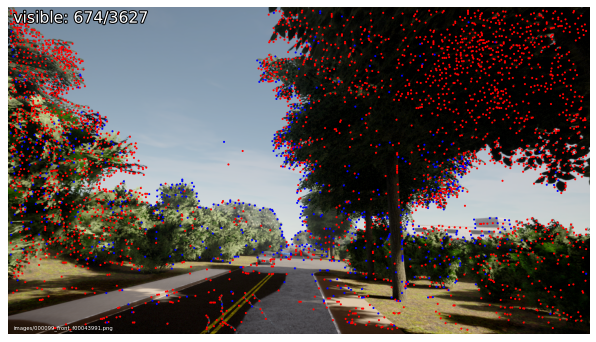

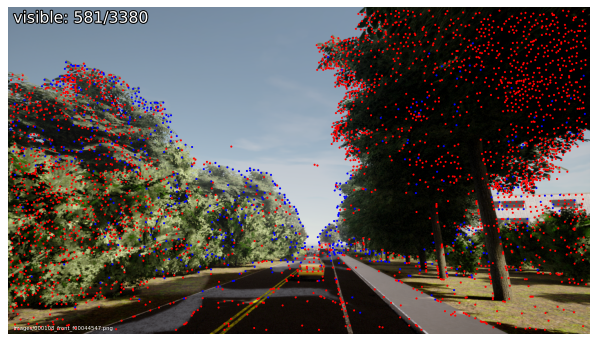

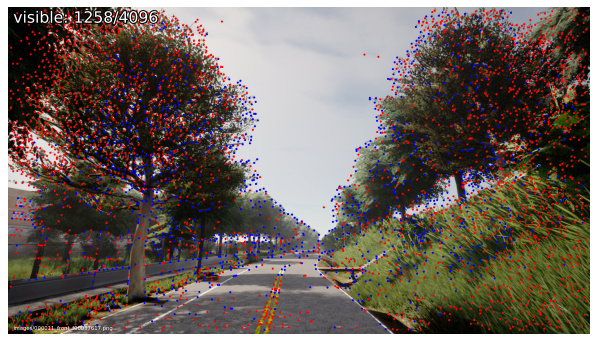

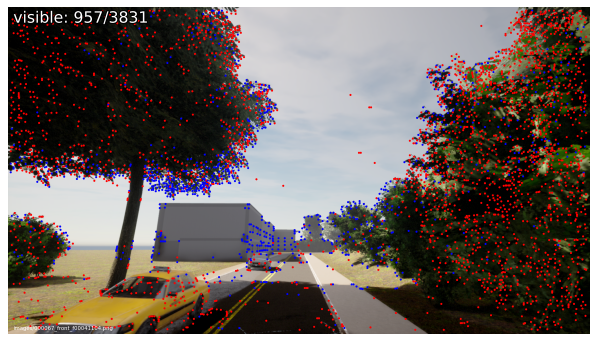

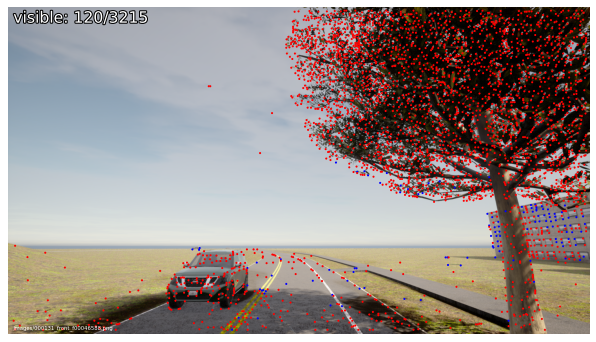

In [11]:
from hloc import visualization

viz_model = pycolmap.Reconstruction(sfm_dir)
visualization.visualize_sfm_2d(viz_model, portable_root, color_by='visibility', n=5)

## 11. 3D Point Cloud Visualization

In [12]:
import plotly.graph_objects as go

xyzs = []
colors = []
for _, p3D in viz_model.points3D.items():
    if p3D.track.length() >= 3:
        xyzs.append(p3D.xyz)
        colors.append(p3D.color)

xyzs = np.array(xyzs)
colors = np.array(colors)
if len(xyzs) == 0:
    print('No 3D points with track length >= 3 to display.')
else:
    color_strings = [f'rgb({int(c[0])}, {int(c[1])}, {int(c[2])})' for c in colors]
    fig = go.Figure(data=[go.Scatter3d(
        x=xyzs[:, 0],
        y=xyzs[:, 1],
        z=xyzs[:, 2],
        mode='markers',
        marker=dict(size=2, color=color_strings, opacity=0.8),
    )])
    fig.update_layout(
        scene=dict(aspectmode='data'),
        title='Known-Pose 3D Reconstruction Point Cloud',
        margin=dict(l=0, r=0, b=0, t=30),
    )
    fig.show()